# Experiment No. 8

## Title
**To create an OpenCV-Python program to smooth a given RGB/Grayscale image by an average filter**

## Objective
To smooth both grayscale and RGB images using an average filter.

## Mathematical Theory
Image smoothing reduces noise and small intensity variations by replacing each pixel with the average value of its neighboring pixels.

A common $3 \times 3$ average filter is:

$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

For grayscale image:

$$
g(x,y)=\frac{1}{9}\sum_{m=-1}^{1}\sum_{n=-1}^{1} f(x+m,y+n)
$$

For RGB image:

$$
g(x,y,c)=\frac{1}{9}\sum_{m=-1}^{1}\sum_{n=-1}^{1} f(x+m,y+n,c)
$$

Where:

- $f(x,y)$ = input pixel value  
- $g(x,y)$ = output pixel value  
- $c$ = color channel (Red, Green, Blue)

The average filter smooths the image by reducing abrupt intensity changes.

## Instruments / Requirements
- Computer or Laptop
- Python
- OpenCV
- NumPy
- Matplotlib
- Input image: `demo_image.jpg`

## Procedure
1. Read the image using OpenCV.
2. If the image is color, convert it from BGR to RGB format.
3. Define the $3 \times 3$ average filter kernel.
4. Apply convolution on each $3 \times 3$ neighborhood.
5. For RGB image, apply the filter separately on each color channel.
6. Store the smoothed image.
7. Display the original and smoothed images.

## Output
- Original image (Grayscale/RGB)
- Smoothed image by average filter

## Result
The smoothed image shows reduced noise and less sharp intensity variation. In RGB images, smoothing is applied separately to each channel.

## Conclusion
Average filtering is a basic smoothing technique used to reduce noise and minor details in both grayscale and RGB images.

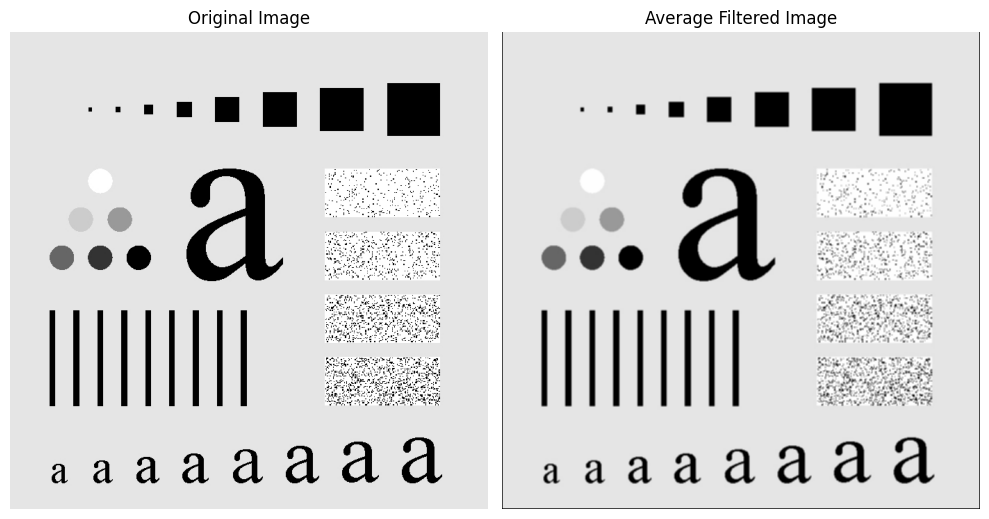

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('Exp8_Demo.jpg')

# Average filter kernel
kernel = np.ones((3, 3), dtype=np.float32) / 9

# Check grayscale or color
if len(img.shape) == 2:
    h, w = img.shape
    smoothed = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            s = 0
            for m in range(-1, 2):
                for n in range(-1, 2):
                    s += img[i + m, j + n] * kernel[m + 1, n + 1]
            smoothed[i, j] = int(s)

    display_img = img
    display_smooth = smoothed
    cmap = 'gray'

else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    smoothed = np.zeros((h, w, c), dtype=np.uint8)

    for k in range(c):
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                s = 0
                for m in range(-1, 2):
                    for n in range(-1, 2):
                        s += img[i + m, j + n, k] * kernel[m + 1, n + 1]
                smoothed[i, j, k] = int(s)

    display_img = img
    display_smooth = smoothed
    cmap = None

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(display_img, cmap=cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_smooth, cmap=cmap)
plt.title("Average Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.savefig('Exp8_Output.png')  # Save full figure
plt.show()